# Cargar Librerias

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Funciones


In [2]:
def col_info(df):
    num_registros = df.shape[0]
    resumen = []

    for c in df.columns:
        null_count = df[c].isnull().sum()
        porc_null = (null_count / num_registros) * 100
        data_types = df[c].dropna().apply(type).unique()
        tipos = [t.__name__ for t in data_types]
        resumen.append({
            'Columna': c,
            'Nulos': null_count,
            '% Nulos': round(porc_null, 2),
            'Tipos de Dato': ', '.join(tipos)
        })

    resumen_df = pd.DataFrame(resumen)
    print(f"Número de registros: {num_registros}")
    return resumen_df

def nulos_referencias(df, col_ref,  col_bsq):
    resumen = df.groupby(col_ref)[col_bsq].agg(
        nulos=lambda x: x.isnull().sum(),
        promedio=lambda x: x.mean(),
        moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    ).reset_index()

    # Filtra solo estaciones con al menos un nulo
    resumen = resumen[resumen['nulos'] > 0]

    return resumen

def mostrar_por_estacion_ordenado(df, col_group='estacion', col_fecha='fecha_med', col_valor='prof_superficie_lvl_agua'):
    # Asegurarse de que la fecha esté en formato datetime
    df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')

    # Ordenar por estación y fecha
    df_ordenado = df[[col_group, col_fecha, col_valor]].sort_values(by=[col_group, col_fecha])

    return df_ordenado

# Cargar Fuente

In [56]:
df_raw = pd.read_csv('/content/drive/MyDrive/Notebooks/DB/Agua/gwl_month.csv')
df_raw.shape
df_raw.head()

,STATION,MSMT_DATE,WLM_RPE,WLM_RPE_QC,WLM_GSE,WLM_GSE_QC,RPE_WSE,RPE_WSE_QC,GSE_WSE,GSE_WSE_QC,WSE,WSE_QC
0,03N04E11L001M,12/1/2022,NaN,255,NaN,255,NaN,255,NaN,255,NaN,255
1,04N04E01N001M,12/1/2022,0.00,1,0.00,1,NaN,255,NaN,255,NaN,255
2,04N04E02B001M,12/1/2022,10.73,1,9.63,1,NaN,255,NaN,255,NaN,255
3,04N04E10Q001M,12/1/2022,NaN,255,NaN,255,NaN,255,NaN,255,NaN,255
4,04N04E10Q002M,12/1/2022,NaN,255,NaN,255,NaN,255,NaN,255,NaN,255


# Analisis del DB

In [57]:
renombrar_columnas = {
    'STATION': 'estacion',
    'MSMT_DATE': 'fecha_med',
    'WLM_RPE': 'punto_ref_elevacion',
    'WLM_RPE_QC': 'calidad_rpe',
    'WLM_GSE': 'elevacion_terreno',
    'WLM_GSE_QC': 'calidad_elv',
    'RPE_WSE': 'elevacion_superfie_agua',
    'RPE_WSE_QC': 'calidad_elvsp_agua',
    'GSE_WSE': 'prof_superficie_lvl_agua',
    'GSE_WSE_QC': 'calidad_prof_sp_lvl_agua',
    'WSE': 'elev_agua',
    'WSE_QC': 'cal_elev_agua'
}

df_raw.rename(columns=renombrar_columnas, inplace=True)

In [58]:
df_eda = df_raw[['punto_ref_elevacion', 'elevacion_terreno', 'elevacion_superfie_agua', 'prof_superficie_lvl_agua', 'elev_agua']]
df_eda.describe()

,punto_ref_elevacion,elevacion_terreno,elevacion_superfie_agua,prof_superficie_lvl_agua,elev_agua
count,80843.000000,80500.000000,65944.000000,65436.000000,65735.000000
mean,342.065483,341.046282,36.269621,34.490961,301.250402
std,973.933330,975.831024,33.236157,33.380057,981.717670
min,-0.570000,-3.170000,-11.949000,-14.749000,-165.659000
25%,45.010000,44.580000,12.892000,11.349750,20.651000
50%,132.450000,129.300000,25.996500,24.198000,95.306000
75%,210.080000,212.410000,49.317000,47.699000,148.613000
max,5495.260000,5492.010000,299.130000,297.010000,5491.840000


In [59]:
df_eda.corr()

,punto_ref_elevacion,elevacion_terreno,elevacion_superfie_agua,prof_superficie_lvl_agua,elev_agua
punto_ref_elevacion,1.000000,0.999998,-0.049483,-0.052461,0.999428
elevacion_terreno,0.999998,1.000000,-0.049585,-0.052313,0.999426
elevacion_superfie_agua,-0.049483,-0.049585,1.000000,0.998496,-0.083245
prof_superficie_lvl_agua,-0.052461,-0.052313,0.998496,1.000000,-0.086117
elev_agua,0.999428,0.999426,-0.083245,-0.086117,1.000000


In [7]:
col_info(df_raw)

Número de registros: 81066


,Columna,Nulos,% Nulos,Tipos de Dato
0,estacion,0,0.00,str
1,fecha_med,0,0.00,str
2,punto_ref_elevacion,223,0.28,float
3,calidad_rpe,0,0.00,int
4,elevacion_terreno,566,0.70,float
5,calidad_elv,0,0.00,int
6,elevacion_superfie_agua,15122,18.65,float
7,calidad_elvsp_agua,0,0.00,int
8,prof_superficie_lvl_agua,15630,19.28,float
9,calidad_prof_sp_lvl_agua,0,0.00,int


In [8]:
nulos_referencias(df_raw, "estacion", "elevacion_superfie_agua")

,estacion,nulos,promedio,moda
0,01N04E36Q001M,74,33.805623,17.283
1,01N04E36Q002M,34,8.773584,8.479
2,01N04E36Q003M,34,18.711817,18.564
3,01N04E36Q004M,63,17.221773,17.172
4,01S04E28F001M,60,16.033554,16.750
...,...,...,...,...
521,48N05E14R001M,21,74.621868,49.591
522,48N05E16P001M,54,76.982202,20.311
523,48N05E25Q001M,3,69.357053,59.996
524,48N05E26D001M,45,59.460738,29.609


In [9]:
nulos_referencias(df_raw, "estacion", "prof_superficie_lvl_agua")

,estacion,nulos,promedio,moda
0,01N04E36Q001M,74,30.784570,13.883
1,01N04E36Q002M,34,6.373584,6.079
2,01N04E36Q003M,34,16.411817,16.264
3,01N04E36Q004M,63,14.821773,14.772
4,01S04E28F001M,60,13.533554,14.250
...,...,...,...,...
521,48N05E14R001M,21,74.461868,49.431
522,48N05E16P001M,54,75.082202,18.411
523,48N05E25Q001M,3,67.857053,58.496
524,48N05E26D001M,45,58.270738,28.419


In [10]:
resultado = mostrar_por_estacion_ordenado(df_raw)
resultado

,estacion,fecha_med,prof_superficie_lvl_agua
73099,01N04E36Q001M,2005-04-01,NaN
72910,01N04E36Q001M,2005-05-01,15.238
72722,01N04E36Q001M,2005-06-01,15.130
72531,01N04E36Q001M,2005-07-01,15.161
72339,01N04E36Q001M,2005-08-01,15.313
...,...,...,...
76828,48N05E36A002M,2003-02-01,122.985
76716,48N05E36A002M,2003-03-01,NaN
76603,48N05E36A002M,2003-04-01,NaN
76485,48N05E36A002M,2003-05-01,NaN


In [65]:
df_raw['fecha'] = pd.to_datetime(df_raw['fecha_med'])
df_raw = df_raw.sort_values(by=['estacion', 'fecha'])
df_raw = df_raw.drop(['elevacion_terreno'], axis=1)

In [66]:
display(df_raw)

,estacion,fecha_med,punto_ref_elevacion,calidad_rpe,calidad_elv,elevacion_superfie_agua,calidad_elvsp_agua,prof_superficie_lvl_agua,calidad_prof_sp_lvl_agua,elev_agua,cal_elev_agua,fecha
73099,01N04E36Q001M,4/1/2005,9.10,1,1,NaN,255,NaN,255,NaN,255,2005-04-01
72910,01N04E36Q001M,5/1/2005,9.10,1,1,17.438,1,15.238,1,-8.338,1,2005-05-01
72722,01N04E36Q001M,6/1/2005,9.10,1,1,17.330,1,15.130,1,-8.230,1,2005-06-01
72531,01N04E36Q001M,7/1/2005,9.10,1,1,17.361,1,15.161,1,-8.261,1,2005-07-01
72339,01N04E36Q001M,8/1/2005,9.10,1,1,17.513,1,15.313,1,-8.413,1,2005-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...
76828,48N05E36A002M,2/1/2003,4139.98,1,1,124.485,1,122.985,1,4015.495,1,2003-02-01
76716,48N05E36A002M,3/1/2003,4139.98,1,1,NaN,151,NaN,151,NaN,151,2003-03-01
76603,48N05E36A002M,4/1/2003,4139.98,1,1,NaN,151,NaN,151,NaN,151,2003-04-01
76485,48N05E36A002M,5/1/2003,4139.98,1,1,NaN,151,NaN,151,NaN,151,2003-05-01


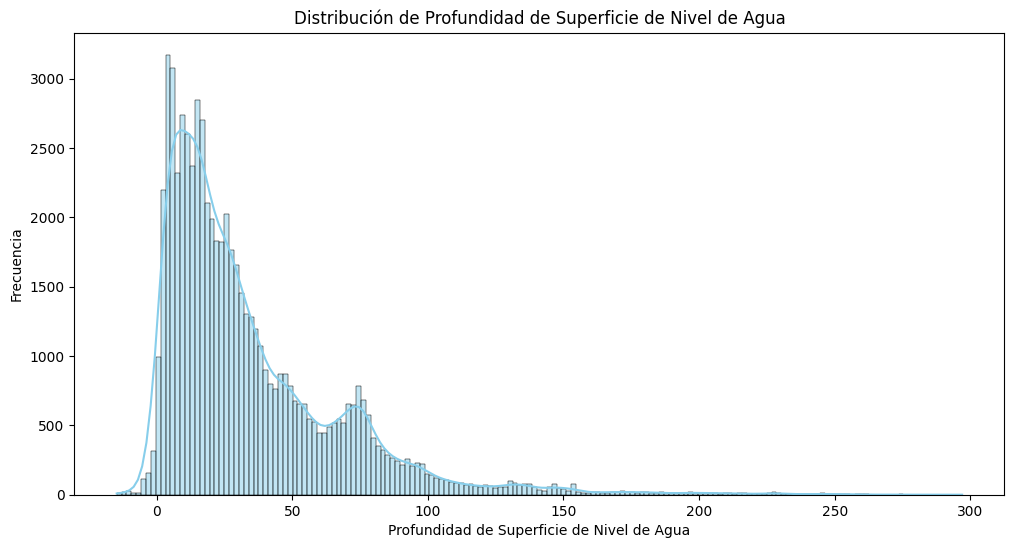

In [48]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_eda["prof_superficie_lvl_agua"], kde=True, color='skyblue')
plt.title("Distribución de Profundidad de Superficie de Nivel de Agua")
plt.xlabel("Profundidad de Superficie de Nivel de Agua")
plt.ylabel("Frecuencia")
plt.show()

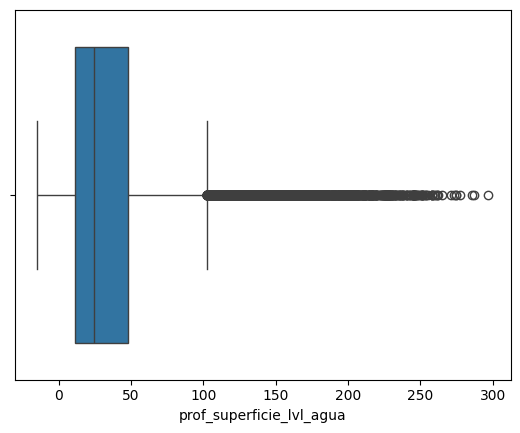

In [16]:
sns.boxplot(x=df_eda['prof_superficie_lvl_agua'])
plt.show()

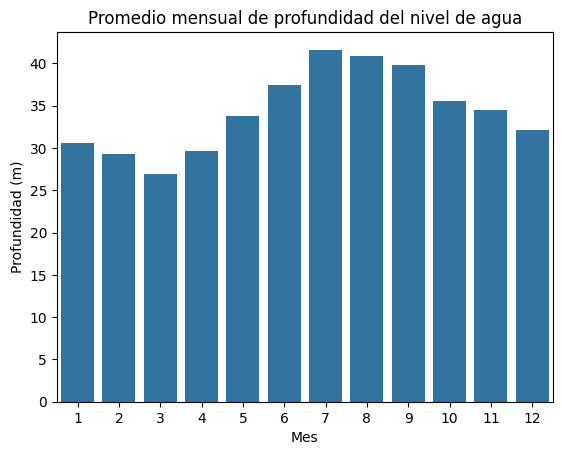

In [17]:
df_raw['mes'] = df_raw['fecha'].dt.month
df_mes_media = df_raw.groupby('mes')['prof_superficie_lvl_agua'].mean()

sns.barplot(x=df_mes_media.index, y=df_mes_media.values)
plt.title("Promedio mensual de profundidad del nivel de agua")
plt.xlabel("Mes")
plt.ylabel("Profundidad (m)")
plt.show()


# Imputacion

Imputamos primero por por fecha y despues si existen valores nulos todavia se usa ffill y bfill

In [49]:
def imputar_serie_tiempo(df, col_fecha, col_group, col_toimp):
    """
    Imputa valores nulos en una serie de tiempo agrupada por estación.

    Parámetros:
        df (pd.DataFrame): Datos de entrada.
        col_fecha (str): Nombre de la columna de fechas.
        col_group (str): Nombre de la columna que identifica estaciones.
        col_toimp (str): Nombre de la columna con valores a imputar.

    Retorna:
        pd.DataFrame con la columna imputada.
    """
    df = df.copy()
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    df = df.sort_values(by=[col_group, col_fecha])

    # Función interna para cada grupo
    def imputar(grupo):
        grupo = grupo.set_index(col_fecha)
        grupo[col_toimp] = grupo[col_toimp].interpolate(method='time')
        grupo[col_toimp] = grupo[col_toimp].ffill().bfill()
        return grupo.reset_index()

    df_imputado = df.groupby(col_group).apply(imputar).reset_index(drop=True)
    return df_imputado

In [67]:
df_imputado = imputar_serie_tiempo(df_raw,"fecha","estacion","prof_superficie_lvl_agua")
df_imputado = imputar_serie_tiempo(df_imputado,"fecha","estacion","elevacion_superfie_agua")

<ipython-input-49-16c5465e76bc>:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_imputado = df.groupby(col_group).apply(imputar).reset_index(drop=True)
<ipython-input-49-16c5465e76bc>:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_imputado = df.groupby(col_group).apply(imputar).reset_index(drop=True)


In [68]:
display(df_imputado)

,fecha,estacion,fecha_med,punto_ref_elevacion,calidad_rpe,calidad_elv,elevacion_superfie_agua,calidad_elvsp_agua,prof_superficie_lvl_agua,calidad_prof_sp_lvl_agua,elev_agua,cal_elev_agua
0,2005-04-01,01N04E36Q001M,4/1/2005,9.10,1,1,17.438,255,15.238,255,NaN,255
1,2005-05-01,01N04E36Q001M,5/1/2005,9.10,1,1,17.438,1,15.238,1,-8.338,1
2,2005-06-01,01N04E36Q001M,6/1/2005,9.10,1,1,17.330,1,15.130,1,-8.230,1
3,2005-07-01,01N04E36Q001M,7/1/2005,9.10,1,1,17.361,1,15.161,1,-8.261,1
4,2005-08-01,01N04E36Q001M,8/1/2005,9.10,1,1,17.513,1,15.313,1,-8.413,1
...,...,...,...,...,...,...,...,...,...,...,...,...
81061,2003-02-01,48N05E36A002M,2/1/2003,4139.98,1,1,124.485,1,122.985,1,4015.495,1
81062,2003-03-01,48N05E36A002M,3/1/2003,4139.98,1,1,124.485,151,122.985,151,NaN,151
81063,2003-04-01,48N05E36A002M,4/1/2003,4139.98,1,1,124.485,151,122.985,151,NaN,151
81064,2003-05-01,48N05E36A002M,5/1/2003,4139.98,1,1,124.485,151,122.985,151,NaN,151


In [52]:
nulos_referencias(df_imputado, "estacion", "prof_superficie_lvl_agua")

,estacion,nulos,promedio,moda
19,03N04E11L001M,26,NaN,NaN
22,04N04E10Q001M,32,NaN,NaN
23,04N04E10Q002M,33,NaN,NaN
26,04N04E13A001M,33,NaN,NaN
27,04N04E13A002M,33,NaN,NaN
28,04N04E34N001M,33,NaN,NaN
29,04N04E34N002M,33,NaN,NaN
171,14N02W22A002M,17,NaN,NaN
225,18N01E21L001M,60,NaN,NaN
254,20N01E13Q002M,58,NaN,NaN


In [69]:
col_info(df_imputado)

Número de registros: 81066


,Columna,Nulos,% Nulos,Tipos de Dato
0,fecha,0,0.00,Timestamp
1,estacion,0,0.00,str
2,fecha_med,0,0.00,str
3,punto_ref_elevacion,223,0.28,float
4,calidad_rpe,0,0.00,int
5,calidad_elv,0,0.00,int
6,elevacion_superfie_agua,8,0.01,float
7,calidad_elvsp_agua,0,0.00,int
8,prof_superficie_lvl_agua,574,0.71,float
9,calidad_prof_sp_lvl_agua,0,0.00,int


Ya que todavia existen algunos valores nulos esto puede ser debido a:

* Estaciones donde todos los valores en esa columna son nulos (sin datos con qué interpolar).

* Estaciones con sólo un valor válido (no se puede interpolar).

* Algunos registros aislados que no pudieron ser completados ni con ffill() ni bfill() porque toda la estación está vacía.

Por ultimo imputamos estos datos con la media. Ya que como podemos ver en la tabla anterior los nulos restantes son menor al 1% de los datos por lo cual no afectan nuestra distribucion.

In [71]:
def rellenar_con_media_por_estacion(df, col_group, col_toimp):
    return df.groupby(col_group)[col_toimp].transform(
        lambda x: x.fillna(x.mean())
    )

columnas_con_nulos = [
    'punto_ref_elevacion',
    'elevacion_superfie_agua',
    'prof_superficie_lvl_agua',
    'elev_agua'
]

for col in columnas_con_nulos:
    df_imputado[col] = rellenar_con_media_por_estacion(df_imputado, col_group='estacion', col_toimp=col)


In [24]:
col_info(df_imputado)

Número de registros: 81066


,Columna,Nulos,% Nulos,Tipos de Dato
0,fecha,0,0.00,Timestamp
1,estacion,0,0.00,str
2,fecha_med,0,0.00,Timestamp
3,punto_ref_elevacion,223,0.28,float
4,calidad_rpe,0,0.00,int
5,elevacion_terreno,566,0.70,float
6,calidad_elv,0,0.00,int
7,elevacion_superfie_agua,8,0.01,float
8,calidad_elvsp_agua,0,0.00,int
9,prof_superficie_lvl_agua,574,0.71,float


Vemos que siguen los valores nulos esto se debe a que hay estaciones donde todos los valores de esa columna son nulos

In [72]:
df_imputado.groupby("estacion")["prof_superficie_lvl_agua"].apply(lambda x: x.notna().sum()).loc[lambda x: x == 0]

,prof_superficie_lvl_agua
estacion,
03N04E11L001M,0
04N04E10Q001M,0
04N04E10Q002M,0
04N04E13A001M,0
04N04E13A002M,0
04N04E34N001M,0
04N04E34N002M,0
14N02W22A002M,0
18N01E21L001M,0


In [73]:
for col in columnas_con_nulos:
    nulos_antes = df_imputado[col].isnull().sum()
    df_imputado[col] = rellenar_con_media_por_estacion(df_imputado, 'estacion', col)
    if df_imputado[col].isnull().sum() > 0:
        df_imputado[col] = df_imputado[col].fillna(df_imputado[col].mean())
    print(f"{col}: {nulos_antes} → {df_imputado[col].isnull().sum()} nulos restantes")


punto_ref_elevacion: 223 → 0 nulos restantes
elevacion_superfie_agua: 8 → 0 nulos restantes
prof_superficie_lvl_agua: 574 → 0 nulos restantes
elev_agua: 231 → 0 nulos restantes


Con lo anterior intentamos rellenar los NaN usando la media de esa columna dentro de cada estación.

 Si todavía quedan nulos (porque había estaciones sin ningún dato), los rellena con la media global de la columna entera, como último recurso.

Con esto ya podemos confirmar que no tenemos valores nulos

In [75]:
df_imputado = df_imputado.drop(['fecha_med'], axis=1)
col_info(df_imputado)

Número de registros: 81066


,Columna,Nulos,% Nulos,Tipos de Dato
0,fecha,0,0.0,Timestamp
1,estacion,0,0.0,str
2,punto_ref_elevacion,0,0.0,float
3,calidad_rpe,0,0.0,int
4,calidad_elv,0,0.0,int
5,elevacion_superfie_agua,0,0.0,float
6,calidad_elvsp_agua,0,0.0,int
7,prof_superficie_lvl_agua,0,0.0,float
8,calidad_prof_sp_lvl_agua,0,0.0,int
9,elev_agua,0,0.0,float


# Random Forest

Dado que este modelo no necesita estandarizar datos dado que no se ven afectados por la escala de las variables pasaremos a la implementacion


In [76]:
df = df_imputado.sort_values(by=['estacion', 'fecha']).reset_index(drop=True)

print(df.columns)

Index(['fecha', 'estacion', 'punto_ref_elevacion', 'calidad_rpe',
       'calidad_elv', 'elevacion_superfie_agua', 'calidad_elvsp_agua',
       'prof_superficie_lvl_agua', 'calidad_prof_sp_lvl_agua', 'elev_agua',
       'cal_elev_agua'],
      dtype='object')


In [77]:
# Variables Calendario
df['mes'] = df['fecha'].dt.month
df['año'] = df['fecha'].dt.year
df['mes_seno'] = np.sin(2 * np.pi * df['mes']/12)
df['mes_coseno'] = np.cos(2 * np.pi * df['mes']/12)


Creamos nuevas columnas que representen los valores pasados (rezagados) del nivel de agua para cada estación. Estas variables permiten al modelo ver cómo estaba el nivel de agua en los meses anteriores.

In [78]:
objetivo = 'prof_superficie_lvl_agua'  # Columna a predecir
n_lags = 12 # Cantidad de meses anteriores que se usarán como input
            # Tomaremos 12 lo equivalente a un año atras
for lag in range(1, n_lags + 1):
    df[f'{objetivo}_lag{lag}'] = df.groupby('estacion')[objetivo].shift(lag)


Eliminamos filas que tengan valores nulos en alguna de las columnas lag

In [79]:
df_rf = df.dropna(subset=[f'{objetivo}_lag{lag}' for lag in range(1, n_lags + 1)])


Dado que RF no trabaja con texto su no con valores numericos categoricos haremos Label Encodig para las estaciones.

In [80]:
le = LabelEncoder()
df_rf['estacion_cod'] = le.fit_transform(df_rf['estacion'])

<ipython-input-80-930b88753256>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rf['estacion_cod'] = le.fit_transform(df_rf['estacion'])


Seleccionamos nuestras entradas y salidas

In [81]:
features = ['mes_seno', 'mes_coseno', 'año', 'estacion_cod'] + [f'{objetivo}_lag{lag}' for lag in range(1, n_lags + 1)]
X = df_rf[features]
y = df_rf[objetivo]


Dividimos nuestros datos en entrenamiento y prueba

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Entrenamiento

In [83]:
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Prediccion del conjunto de Pruebas

In [84]:
y_pred = modelo_rf.predict(X_test)

Evaluacion

In [85]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Resultados del modelo Random Forest:")
print(f"  RMSE: {rmse:.3f}")
print(f"  MAE : {mae:.3f}")
print(f"  R²  : {r2:.3f}")

Resultados del modelo Random Forest:
  RMSE: 5.858
  MAE : 1.712
  R²  : 0.971


Tomemos en cuenta que:
RMSE: El error cuadrático medio es relativamente bajo.

MAE: En promedio, el modelo se equivoca por ~1.7 pies(ft).

R²: El modelo explica el 97% de la varianza en los datos, lo cual indica un muy buen ajuste.

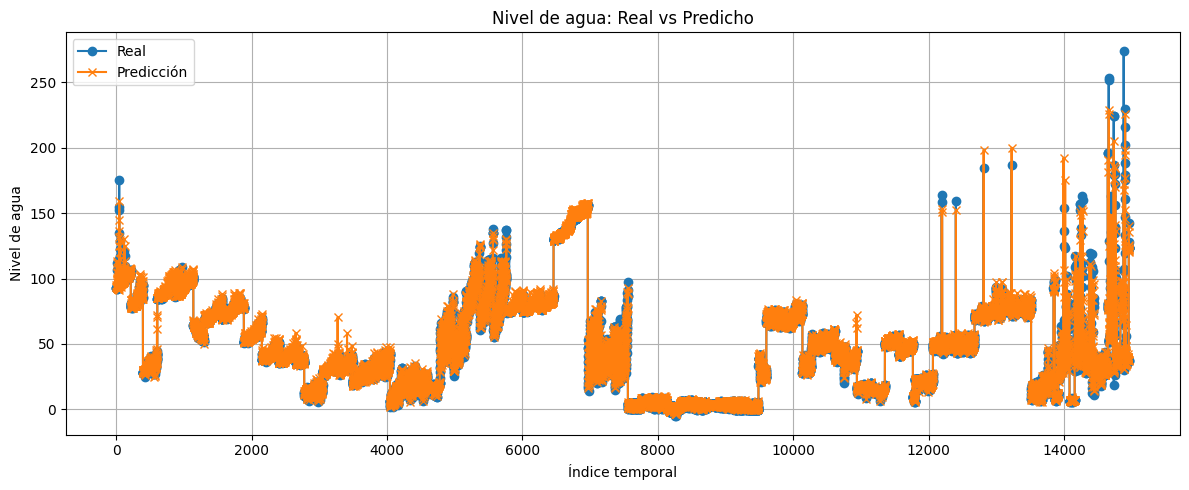

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Real', marker='o')
plt.plot(y_pred, label='Predicción', marker='x')
plt.title("Nivel de agua: Real vs Predicho")
plt.xlabel("Índice temporal")
plt.ylabel("Nivel de agua")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Prediccion

In [88]:
# Variable objetivo
objetivo = 'prof_superficie_lvl_agua'
n_lags = 12
n_futuro = 12  # Número de meses que quieres predecir

# Seleccion de estación
estacion_objetivo = df_rf['estacion'].unique()[4]
df_estacion = df_rf[df_rf['estacion'] == estacion_objetivo].copy()

# Tomar la última fecha y valores de lags
fecha_actual = df_estacion['fecha'].max()
lags_actuales = [df_estacion[objetivo].iloc[-i] for i in range(1, n_lags + 1)]
estacion_cod = df_estacion['estacion_cod'].iloc[-1]

In [89]:
predicciones = []

for i in range(n_futuro):
    fecha_futura = fecha_actual + pd.DateOffset(months=1)
    mes = fecha_futura.month
    año = fecha_futura.year

    nueva_fila = {
        'mes_seno': np.sin(2 * np.pi * mes / 12),
        'mes_coseno': np.cos(2 * np.pi * mes / 12),
        'año': año,
        'estacion_cod': estacion_cod,
    }

    for j in range(1, n_lags + 1):
        nueva_fila[f'{objetivo}_lag{j}'] = lags_actuales[j - 1]

    X_futuro = pd.DataFrame([nueva_fila])[features]

    # Predecir
    pred = modelo_rf.predict(X_futuro)[0]

    # Guardar resultado
    predicciones.append({'fecha': fecha_futura, 'predicho': pred})

    # Actualizar lags
    lags_actuales = [pred] + lags_actuales[:-1]
    fecha_actual = fecha_futura


In [90]:
df_pred_futuro = pd.DataFrame(predicciones)
print(df_pred_futuro)

        fecha   predicho
0  2019-08-01  13.093735
1  2019-09-01  13.254487
2  2019-10-01  13.409936
3  2019-11-01  13.448220
4  2019-12-01  13.419952
5  2020-01-01  13.444282
6  2020-02-01  13.437343
7  2020-03-01  13.477316
8  2020-04-01  13.515896
9  2020-05-01  13.610120
10 2020-06-01  13.759717
11 2020-07-01  14.926785


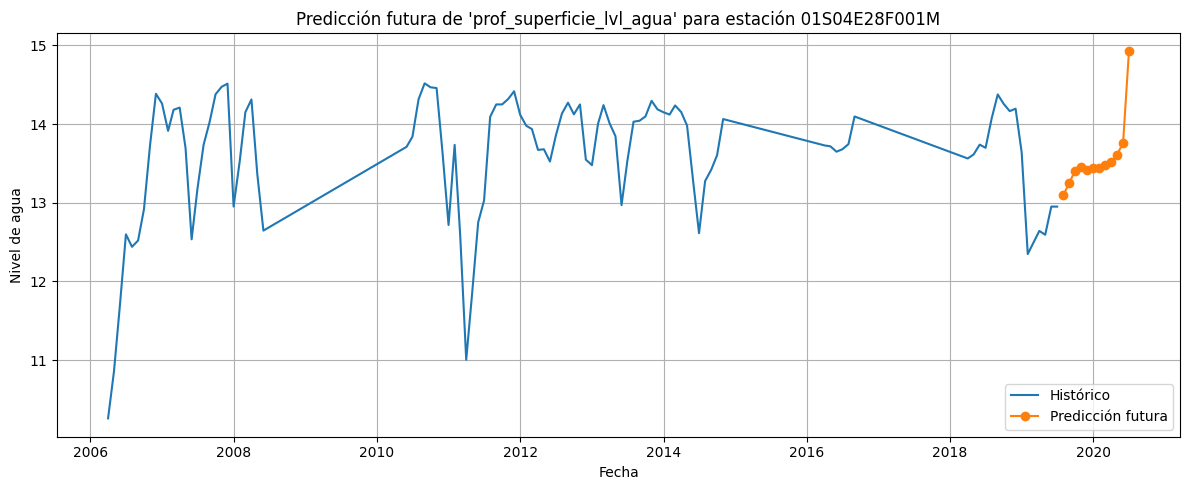

In [91]:
plt.figure(figsize=(12, 5))
plt.plot(df_estacion['fecha'], df_estacion[objetivo], label='Histórico')
plt.plot(df_pred_futuro['fecha'], df_pred_futuro['predicho'], label='Predicción futura', marker='o')
plt.title(f"Predicción futura de '{objetivo}' para estación {estacion_objetivo}")
plt.xlabel("Fecha")
plt.ylabel("Nivel de agua")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [92]:
fechas = []
medianas = []
p25s = []
p75s = []
p10s = []
p90s = []

lags_actuales = [df_estacion[objetivo].iloc[-i] for i in range(1, n_lags + 1)]
fecha_actual = df_estacion['fecha'].max()

for i in range(n_futuro):
    fecha_futura = fecha_actual + pd.DateOffset(months=1)
    mes = fecha_futura.month
    año = fecha_futura.year

    entrada = {
        'mes_seno': np.sin(2 * np.pi * mes / 12),
        'mes_coseno': np.cos(2 * np.pi * mes / 12),
        'año': año,
        'estacion_cod': estacion_cod,
    }
    for j in range(1, n_lags + 1):
        entrada[f'{objetivo}_lag{j}'] = lags_actuales[j - 1]

    X_futuro = pd.DataFrame([entrada])[features]

    # Predicción de todos los árboles del bosque
    pred_arboles = np.array([arbol.predict(X_futuro)[0] for arbol in modelo_rf.estimators_])

    # Guardar estadísticas
    fechas.append(fecha_futura)
    medianas.append(np.median(pred_arboles))
    p25s.append(np.percentile(pred_arboles, 25))
    p75s.append(np.percentile(pred_arboles, 75))
    p10s.append(np.percentile(pred_arboles, 10))
    p90s.append(np.percentile(pred_arboles, 90))

    # Actualizar lags
    nueva_pred = np.median(pred_arboles)
    lags_actuales = [nueva_pred] + lags_actuales[:-1]
    fecha_actual = fecha_futura


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWa

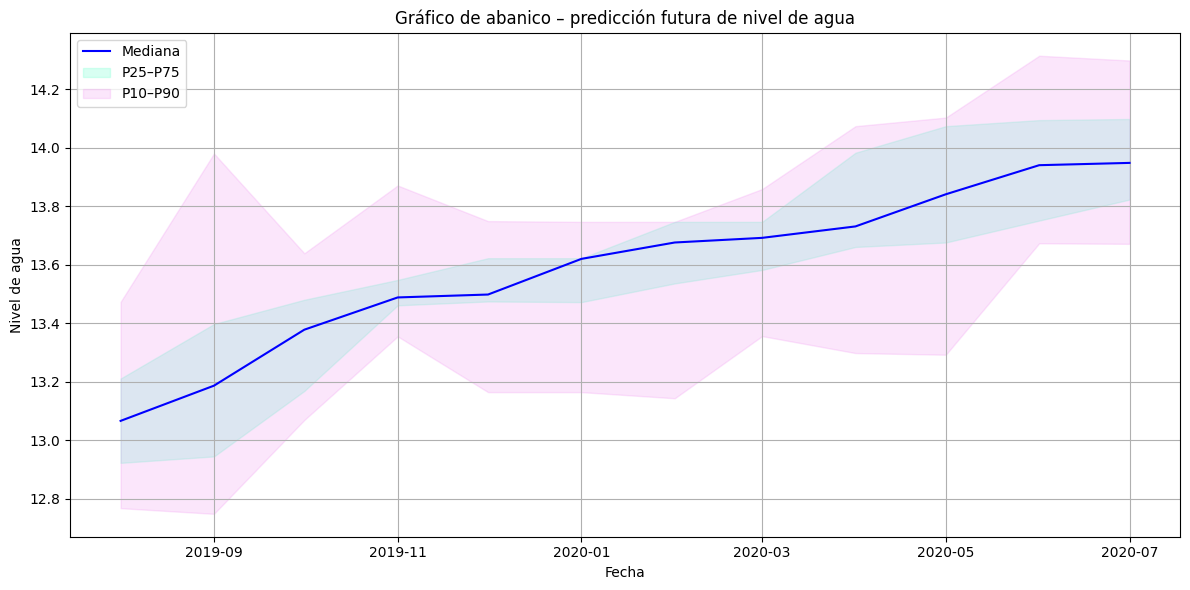

In [93]:
plt.figure(figsize=(12, 6))
plt.plot(fechas, medianas, label='Mediana', color='blue')
plt.fill_between(fechas, p25s, p75s, alpha=0.3, label='P25–P75', color='aquamarine')
plt.fill_between(fechas, p10s, p90s, alpha=0.2, label='P10–P90', color='violet')
plt.title("Gráfico de abanico – predicción futura de nivel de agua")
plt.xlabel("Fecha")
plt.ylabel("Nivel de agua")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [94]:
from sklearn.linear_model import LinearRegression

# Parámetros
n_futuro = 6
umbral_peligro = 1.0
estaciones_riesgo = []

# Listado de estaciones
for estacion in df_rf['estacion'].unique():
    df_est = df_rf[df_rf['estacion'] == estacion].copy()

    if len(df_est) < n_lags + 1:
        continue

    # Obtener últimos lags y codificación
    lags_actuales = [df_est[objetivo].iloc[-i] for i in range(1, n_lags + 1)]
    estacion_cod = df_est['estacion_cod'].iloc[-1]
    fecha_actual = df_est['fecha'].max()

    pred_fut = []

    for i in range(n_futuro):
        mes = (fecha_actual + pd.DateOffset(months=i+1)).month
        año = (fecha_actual + pd.DateOffset(months=i+1)).year

        entrada = {
            'mes_seno': np.sin(2 * np.pi * mes / 12),
            'mes_coseno': np.cos(2 * np.pi * mes / 12),
            'año': año,
            'estacion_cod': estacion_cod,
        }
        for j in range(1, n_lags + 1):
            entrada[f'{objetivo}_lag{j}'] = lags_actuales[j - 1]

        X_futuro = pd.DataFrame([entrada])[features]
        pred = modelo_rf.predict(X_futuro)[0]
        pred_fut.append(pred)
        lags_actuales = [pred] + lags_actuales[:-1]

    # Análisis de tendencia
    x = np.arange(n_futuro).reshape(-1, 1)
    y = np.array(pred_fut)
    reg = LinearRegression().fit(x, y)
    pendiente = reg.coef_[0]

    # Criterios de alerta
    if pendiente < -0.3 or y[-1] < umbral_peligro:
        estaciones_riesgo.append({
            'estacion': estacion,
            'pendiente': pendiente,
            'nivel_final': y[-1],
            'nivel_inicial': y[0],
            'diferencia': y[-1] - y[0]
        })


In [95]:
df_riesgo = pd.DataFrame(estaciones_riesgo).sort_values('pendiente')
print(df_riesgo)

          estacion  pendiente  nivel_final  nivel_inicial  diferencia
254  48N05E14R001M -21.688439    97.635891     197.717441 -100.081550
253  48N04E35C001M -20.125360    44.257547     155.613136 -111.355589
181  22N02W30H002M  -8.591439   135.878965     179.436157  -43.557192
152  21N02W36A001M  -7.320962    28.052693      64.217325  -36.164631
173  22N02W01N002M  -6.933378    31.768825      67.186536  -35.417712
..             ...        ...          ...            ...         ...
0    05N03E09L001M  -0.310131    18.320365      19.777642   -1.457277
30   12N01W04M001M  -0.306381   114.785314     116.139889   -1.354574
122  20N02W25F004M  -0.300989    10.894448      12.086843   -1.192395
38   12N02E23H002M  -0.300690     7.725638       9.151233   -1.425595
76   16N03W14H003M   0.241314    -2.148918      -3.405682    1.256764

[255 rows x 5 columns]


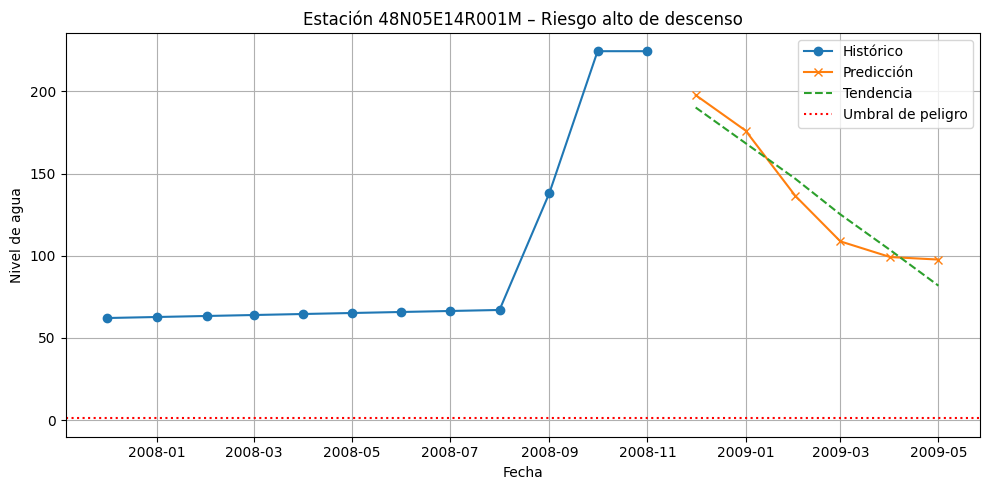

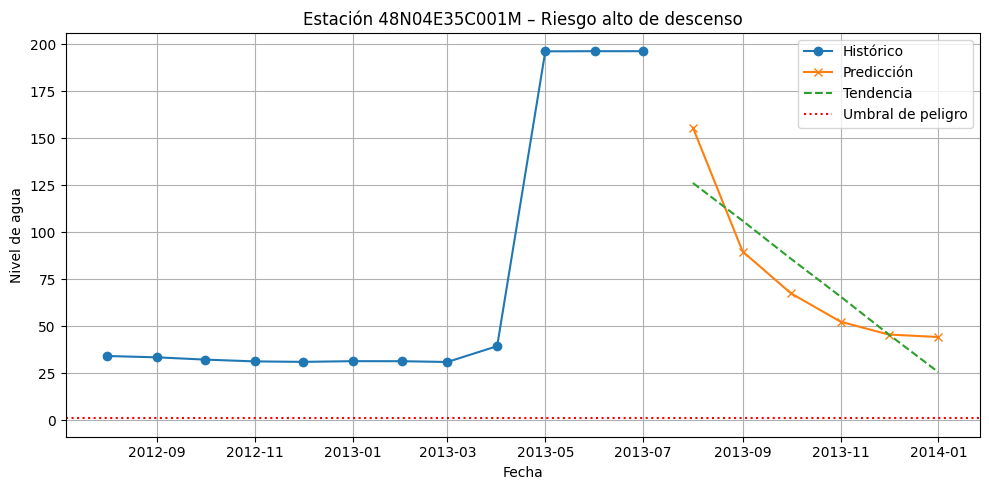

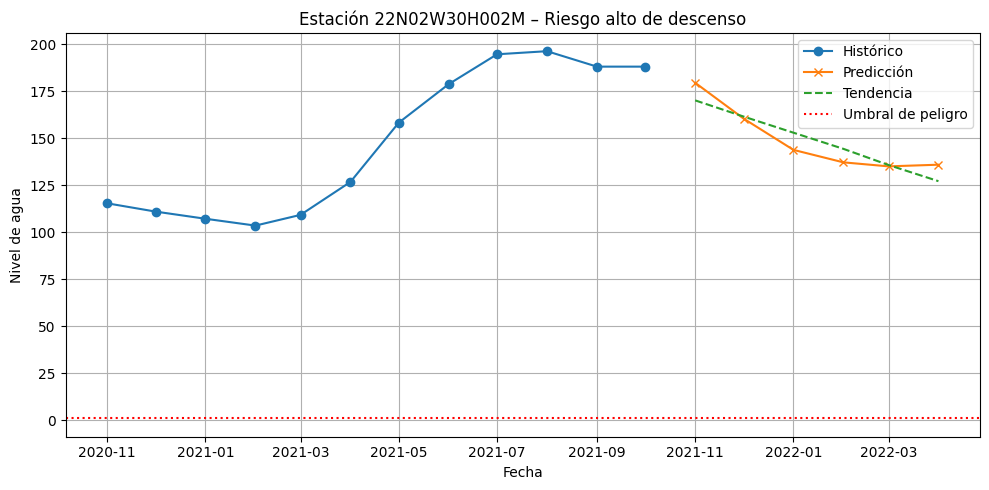

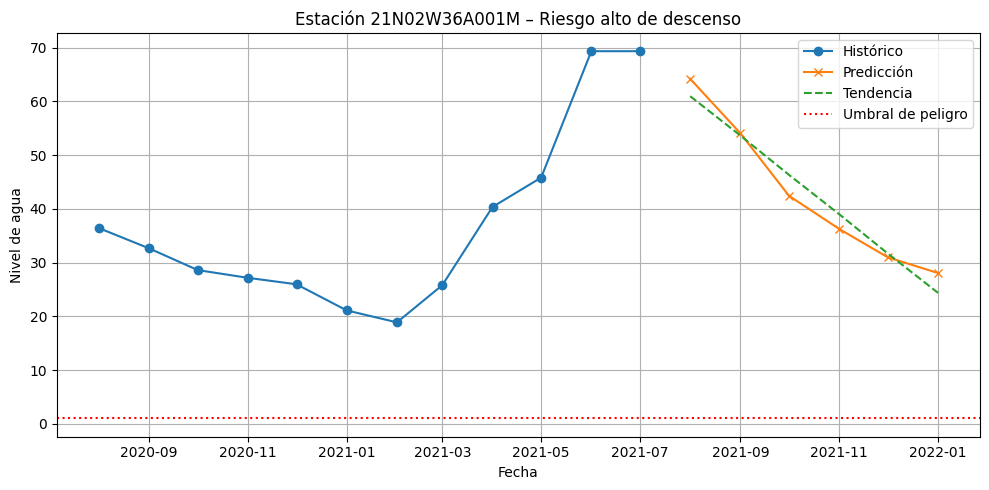

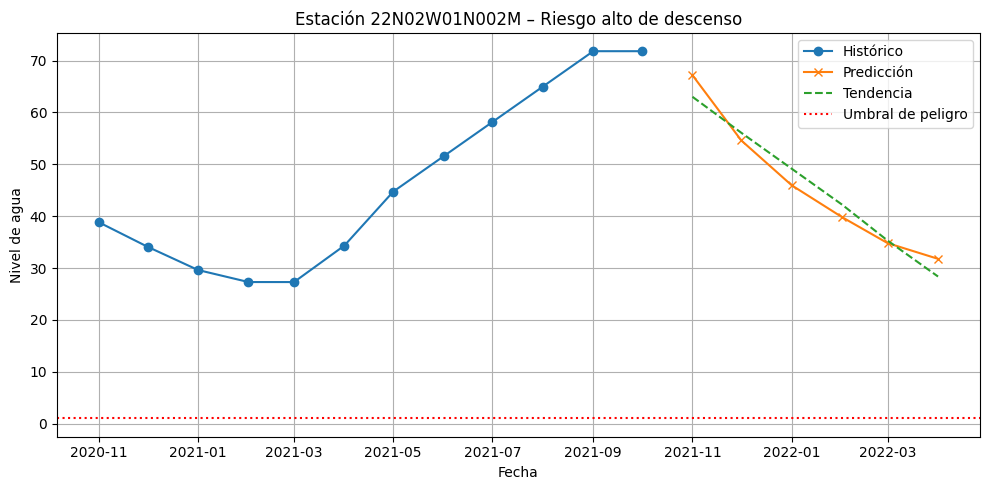

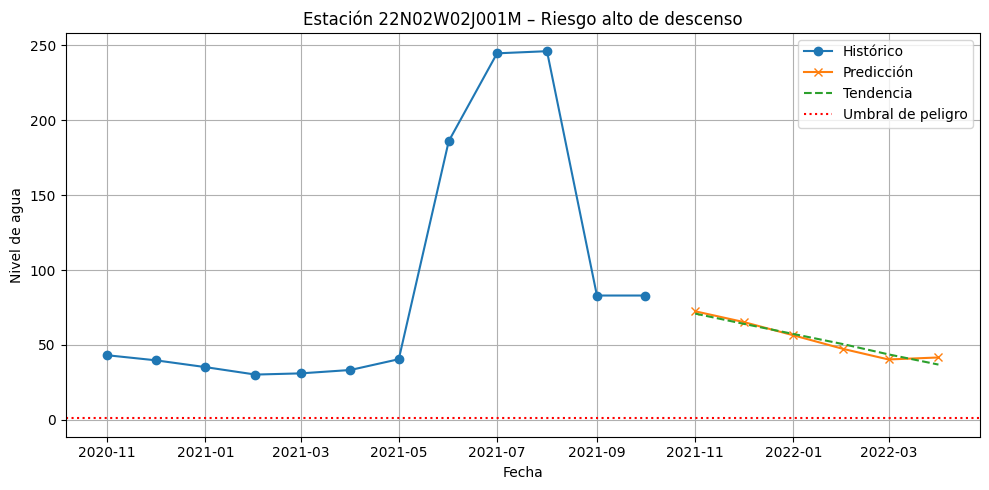

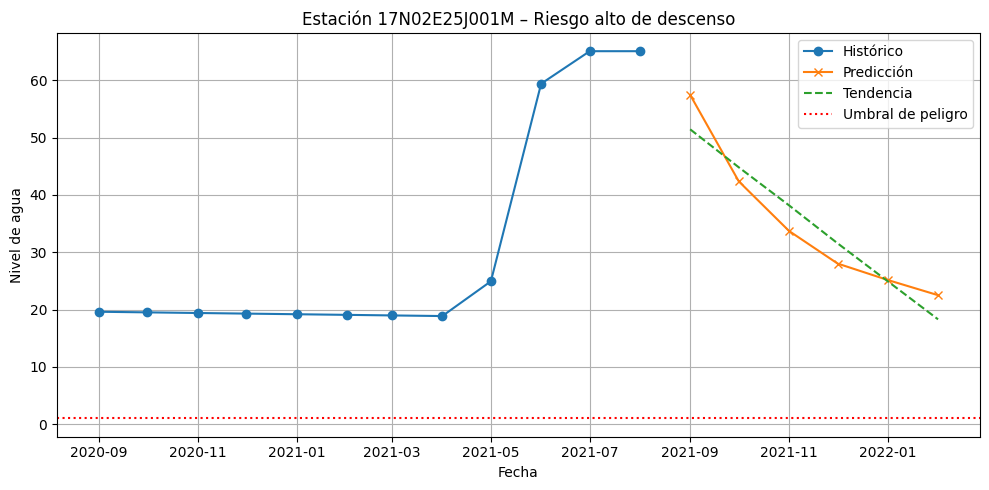

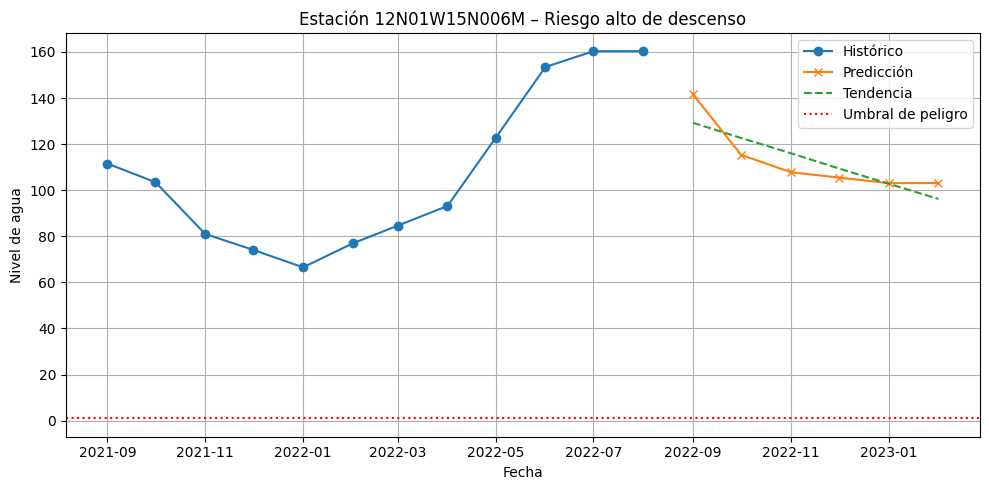

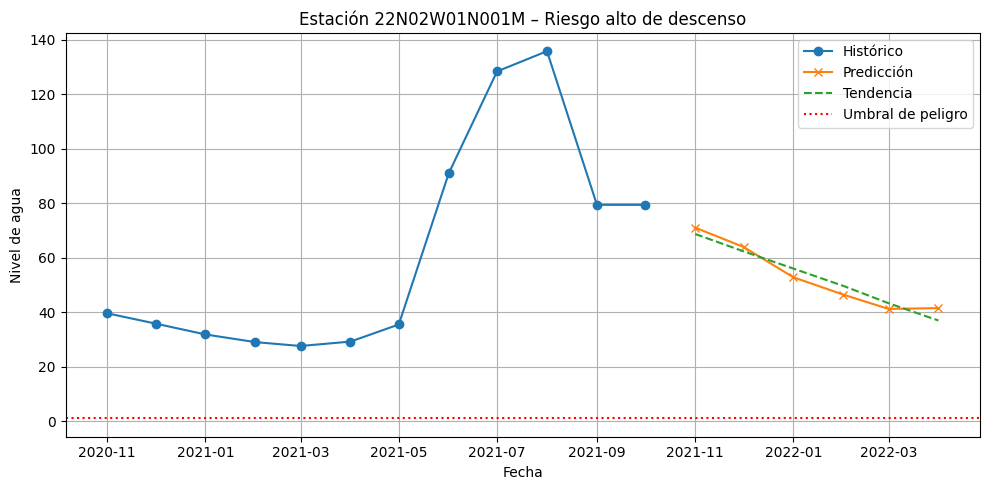

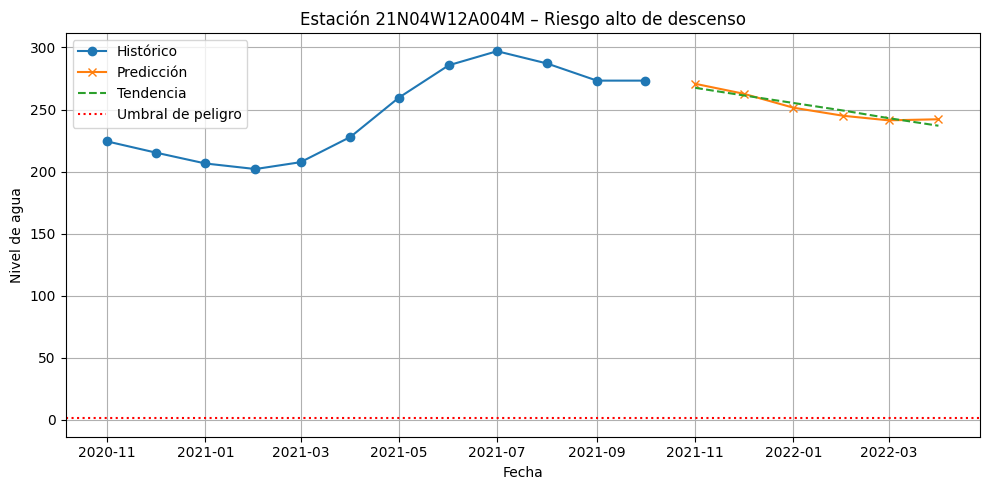

In [96]:
top10 = df_riesgo.sort_values('pendiente').head(10)

for fila in top10.itertuples():
    estacion = fila.estacion
    df_est = df_rf[df_rf['estacion'] == estacion].copy()

    # Últimos valores reales
    historial = df_est[['fecha', objetivo]].tail(12)

    # Últimos lags y metadatos
    lags_actuales = [df_est[objetivo].iloc[-i] for i in range(1, n_lags + 1)]
    estacion_cod = df_est['estacion_cod'].iloc[-1]
    fecha_actual = df_est['fecha'].max()

    pred_fut = []
    fechas_fut = []

    for i in range(n_futuro):
        fecha_futura = fecha_actual + pd.DateOffset(months=i+1)
        entrada = {
            'mes_seno': np.sin(2 * np.pi * fecha_futura.month / 12),
            'mes_coseno': np.cos(2 * np.pi * fecha_futura.month / 12),
            'año': fecha_futura.year,
            'estacion_cod': estacion_cod
        }
        for j in range(1, n_lags + 1):
            entrada[f'{objetivo}_lag{j}'] = lags_actuales[j - 1]

        X_futuro = pd.DataFrame([entrada])[features]
        pred = modelo_rf.predict(X_futuro)[0]
        pred_fut.append(pred)
        fechas_fut.append(fecha_futura)
        lags_actuales = [pred] + lags_actuales[:-1]

    # Tendencia
    x = np.arange(n_futuro).reshape(-1, 1)
    y_pred = np.array(pred_fut)
    y_trend = LinearRegression().fit(x, y_pred).predict(x)

    plt.figure(figsize=(10, 5))
    plt.plot(historial['fecha'], historial[objetivo], label='Histórico', marker='o')
    plt.plot(fechas_fut, y_pred, label='Predicción', marker='x')
    plt.plot(fechas_fut, y_trend, '--', label='Tendencia')
    plt.axhline(y=umbral_peligro, color='r', linestyle=':', label='Umbral de peligro')
    plt.title(f'Estación {estacion} – Riesgo alto de descenso')
    plt.xlabel('Fecha')
    plt.ylabel('Nivel de agua')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [118]:
top10 = df_riesgo.sort_values('pendiente').head(10)

print("Ranking de estaciones con mayor riesgo de descenso en nivel de agua:")
for i, estacion in enumerate(top10['estacion'], start=1):
    print(f"{i}. {estacion}")

Ranking de estaciones con mayor riesgo de descenso en nivel de agua:
1. 48N05E14R001M
2. 48N04E35C001M
3. 22N02W30H002M
4. 21N02W36A001M
5. 22N02W01N002M
6. 22N02W02J001M
7. 17N02E25J001M
8. 12N01W15N006M
9. 22N02W01N001M
10. 21N04W12A004M


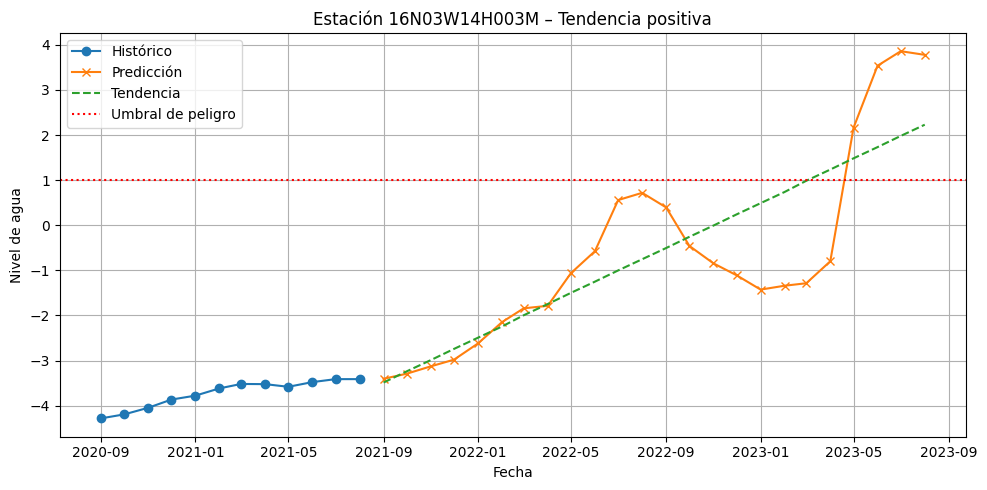

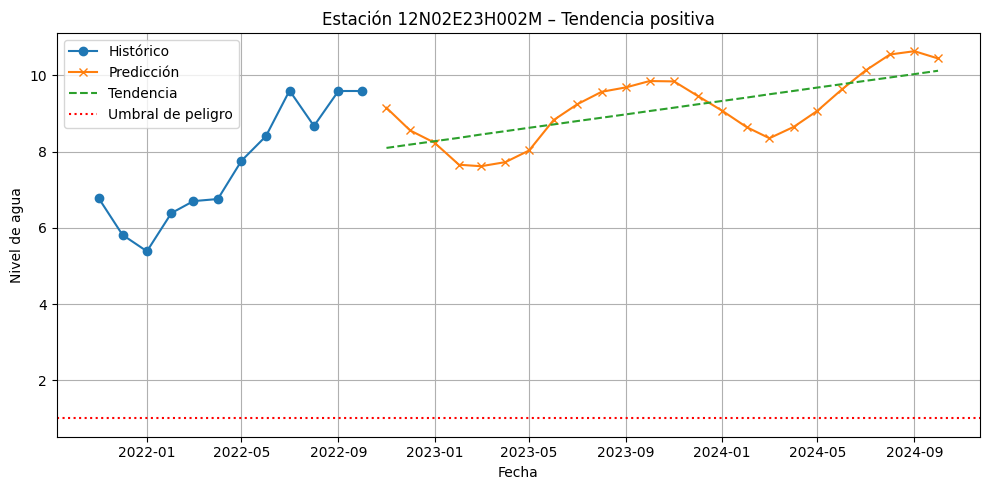

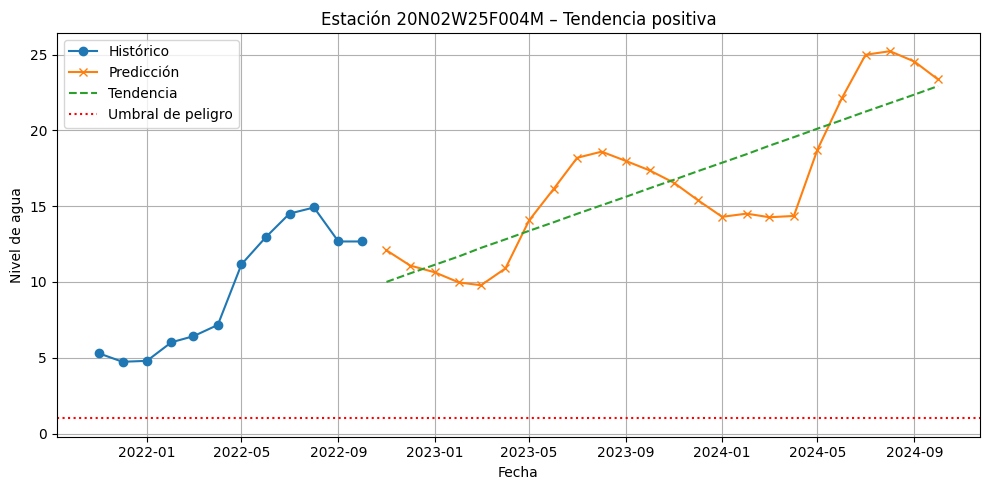

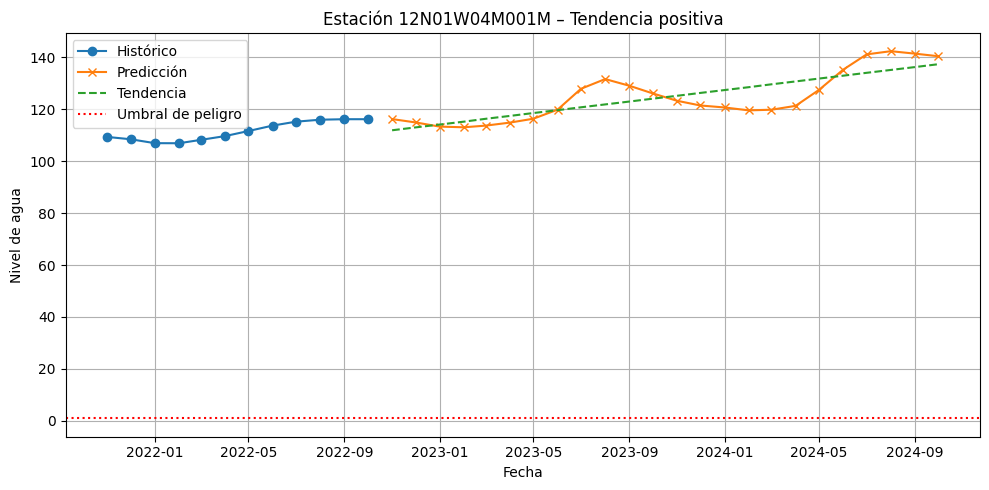

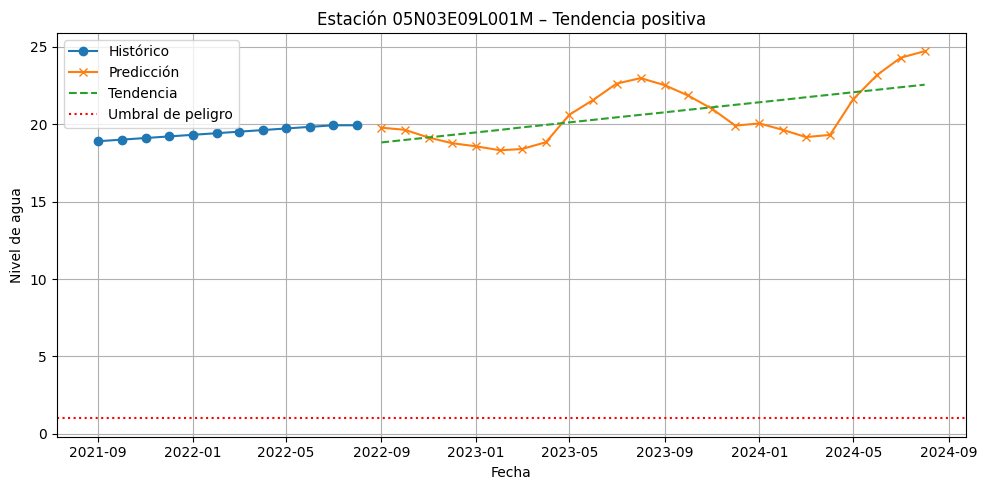

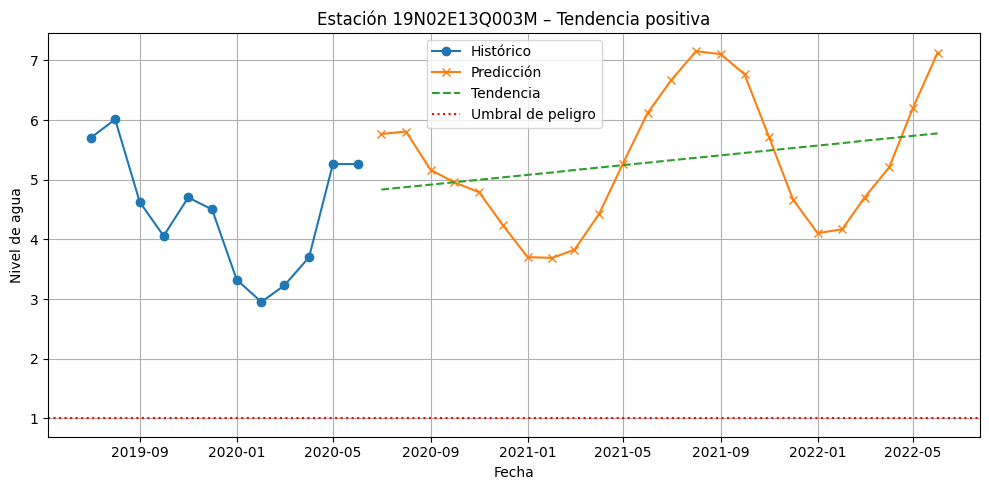

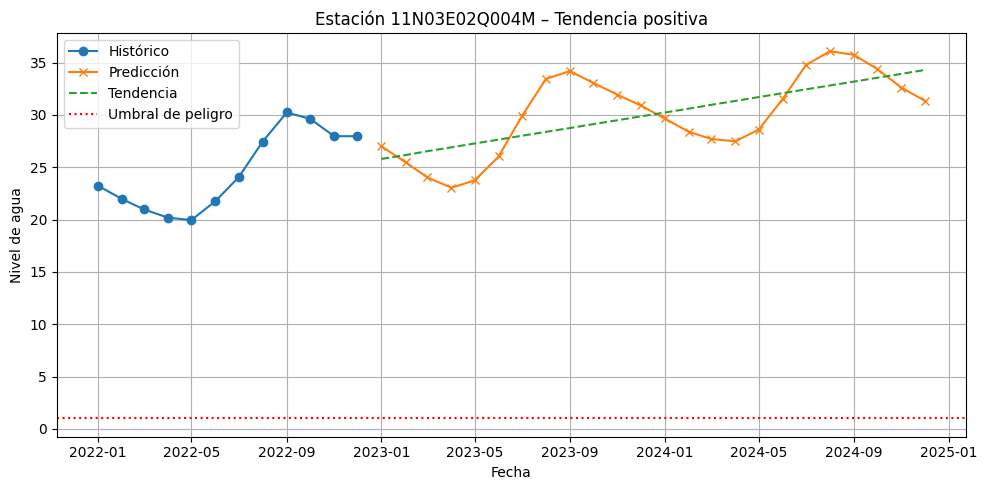

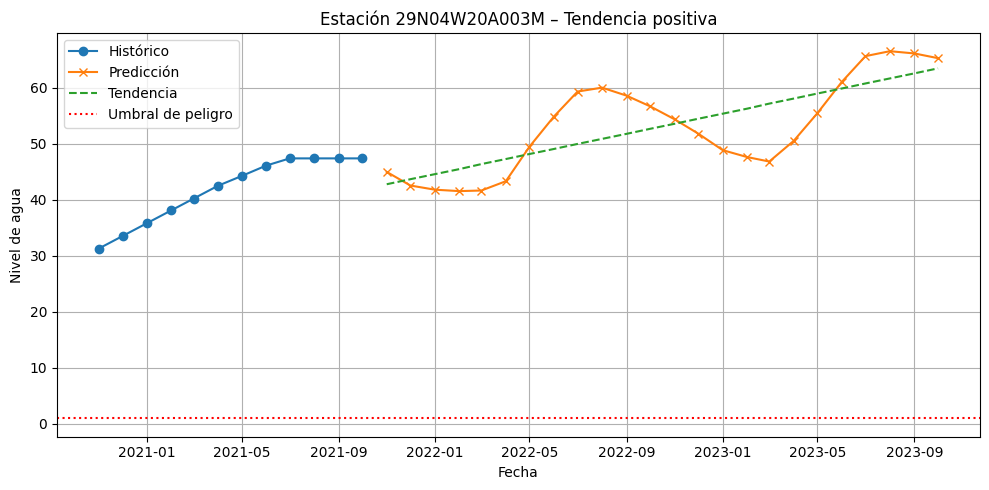

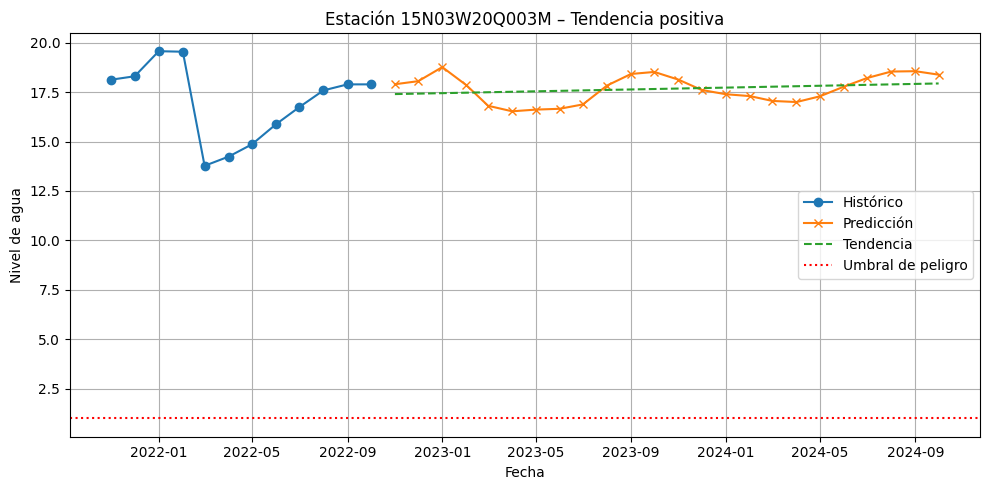

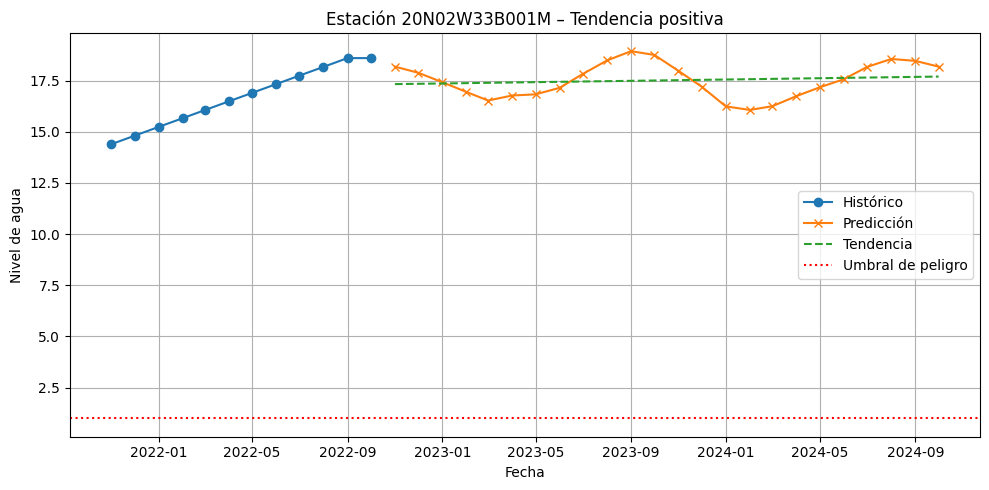

In [119]:
top10_ascenso = df_riesgo.sort_values('pendiente', ascending=False).head(10)

for fila in top10_ascenso.itertuples():
    estacion = fila.estacion
    df_est = df_rf[df_rf['estacion'] == estacion].copy()

    # Últimos valores reales
    historial = df_est[['fecha', objetivo]].tail(12)

    # Últimos lags y metadatos
    lags_actuales = [df_est[objetivo].iloc[-i] for i in range(1, n_lags + 1)]
    estacion_cod = df_est['estacion_cod'].iloc[-1]
    fecha_actual = df_est['fecha'].max()

    pred_fut = []
    fechas_fut = []

    for i in range(n_futuro):
        fecha_futura = fecha_actual + pd.DateOffset(months=i+1)
        entrada = {
            'mes_seno': np.sin(2 * np.pi * fecha_futura.month / 12),
            'mes_coseno': np.cos(2 * np.pi * fecha_futura.month / 12),
            'año': fecha_futura.year,
            'estacion_cod': estacion_cod
        }
        for j in range(1, n_lags + 1):
            entrada[f'{objetivo}_lag{j}'] = lags_actuales[j - 1]

        X_futuro = pd.DataFrame([entrada])[features]
        pred = modelo_rf.predict(X_futuro)[0]
        pred_fut.append(pred)
        fechas_fut.append(fecha_futura)
        lags_actuales = [pred] + lags_actuales[:-1]

    # Tendencia lineal
    x = np.arange(n_futuro).reshape(-1, 1)
    y_pred = np.array(pred_fut)
    y_trend = LinearRegression().fit(x, y_pred).predict(x)

    plt.figure(figsize=(10, 5))
    plt.plot(historial['fecha'], historial[objetivo], label='Histórico', marker='o')
    plt.plot(fechas_fut, y_pred, label='Predicción', marker='x')
    plt.plot(fechas_fut, y_trend, '--', label='Tendencia')
    plt.axhline(y=umbral_peligro, color='r', linestyle=':', label='Umbral de peligro')
    plt.title(f'Estación {estacion} – Tendencia positiva')
    plt.xlabel('Fecha')
    plt.ylabel('Nivel de agua')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [122]:
top10_ascenso = df_riesgo.sort_values('pendiente', ascending=False).head(10)

print("Ranking de estaciones con mayor tendencia de aumento en nivel de agua:")
for i, estacion in enumerate(top10_ascenso['estacion'], start=1):
    print(f"{i}. {estacion}")

Ranking de estaciones con mayor tendencia de aumento en nivel de agua:
1. 16N03W14H003M
2. 12N02E23H002M
3. 20N02W25F004M
4. 12N01W04M001M
5. 05N03E09L001M
6. 19N02E13Q003M
7. 11N03E02Q004M
8. 29N04W20A003M
9. 15N03W20Q003M
10. 20N02W33B001M


# LSTM

In [97]:
df_rf['estacion'].unique()[4]

'01S04E28F001M'

In [98]:
# Estacion Objetivo
estacion_prueba = '01S04E28F001M'
df_est = df_rf[df_rf['estacion'] == estacion_prueba].copy()

# Ordenar por fecha
df_est = df_est.sort_values('fecha')

# Crear variables
df_est['mes'] = df_est['fecha'].dt.month
df_est['mes_seno'] = np.sin(2 * np.pi * df_est['mes'] / 12)
df_est['mes_coseno'] = np.cos(2 * np.pi * df_est['mes'] / 12)

# Columnas para entrenamiento
variables = ['mes_seno', 'mes_coseno']
objetivo = 'prof_superficie_lvl_agua'

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X = scaler_x.fit_transform(df_est[variables])
y = scaler_y.fit_transform(df_est[[objetivo]])

# Crear secuencias para LSTM
def crear_secuencias(X, y, n_lags):
    X_seq, y_seq = [], []
    for i in range(n_lags, len(X)):
        X_seq.append(X[i - n_lags:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

n_lags = 12
X_seq, y_seq = crear_secuencias(X, y, n_lags)

# Dividir en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.3137 - val_loss: 0.0310
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0628 - val_loss: 0.0106
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0274 - val_loss: 0.0025
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0296 - val_loss: 0.0012
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0362 - val_loss: 0.0011
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0265 - val_loss: 0.0018
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0277 - val_loss: 9.9183e-04
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0280 - val_loss: 0.0016
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0290 - val_loss: 0.0020
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0303 - val_loss: 0.0011
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0307 - val_loss: 0.0025
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
RMSE: 0.333, MAE: 0.206, R²: 0.598


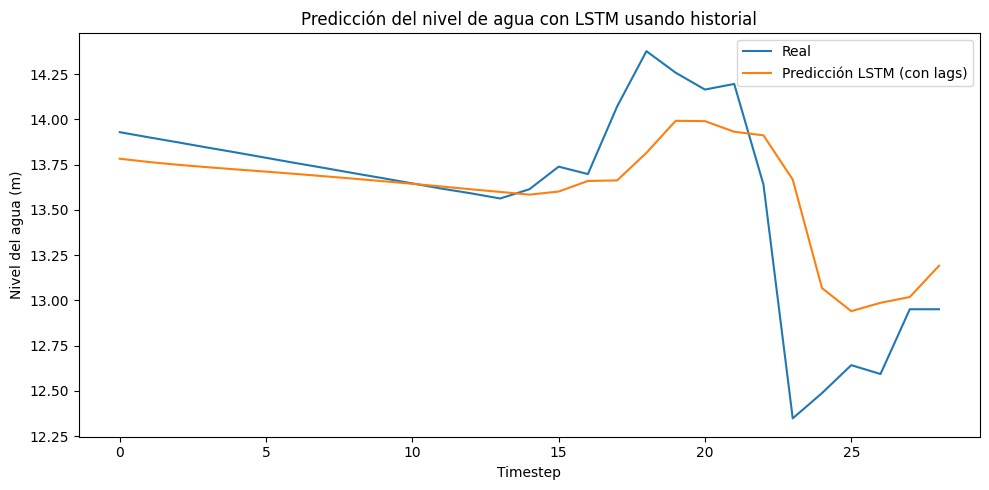

In [115]:
# Seleccionar estación
estacion = '01S04E28F001M'
df_est = df_rf[df_rf['estacion'] == estacion].copy()
df_est = df_est.sort_values('fecha')
df_est['fecha'] = pd.to_datetime(df_est['fecha'], errors='coerce')
df_est = df_est.dropna(subset=['fecha', 'prof_superficie_lvl_agua'])

# Escalado del objetivo
scaler_y = MinMaxScaler()
y = scaler_y.fit_transform(df_est[['prof_superficie_lvl_agua']])

# Crear secuencias con el historial del nivel de agua
def crear_secuencias_con_objetivo(y, n_lags):
    X_seq, y_seq = [], []
    for i in range(n_lags, len(y)):
        X_seq.append(y[i - n_lags:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

n_lags = 18
X_seq, y_seq = crear_secuencias_con_objetivo(y, n_lags)

# Ajustar la forma para LSTM (samples, timesteps, features)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

# --- Entrenamiento ---
model = Sequential()
model.add(LSTM(64, activation='tanh', input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_split=0.2, verbose=1)

# --- Evaluación ---
y_pred = model.predict(X_test)

# Invertir escalado
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f'RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}')

# --- Visualización ---
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='Real')
plt.plot(y_pred_inv, label='Predicción LSTM (con lags)')
plt.title('Predicción del nivel de agua con LSTM usando historial')
plt.xlabel('Timestep')
plt.ylabel('Nivel del agua (m)')
plt.legend()
plt.tight_layout()
plt.show()


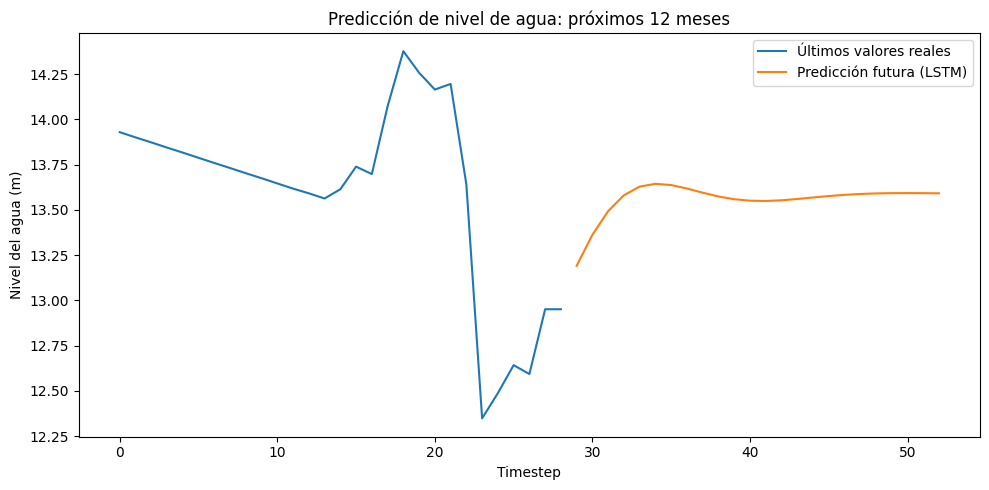

In [117]:
# Número de pasos a futuro
n_futuro = 24

ultima_secuencia = X_seq[-1]

predicciones_futuras = []

secuencia_actual = ultima_secuencia.copy()

for _ in range(n_futuro):
    entrada = secuencia_actual.reshape((1, n_lags, 1))
    pred = model.predict(entrada, verbose=0)
    predicciones_futuras.append(pred[0, 0])

    # Actualizar la secuencia desplazando a la izquierda y agregando la nueva predicción
    secuencia_actual = np.append(secuencia_actual[1:], [[pred[0, 0]]], axis=0)

# Invertir escalado
predicciones_futuras_inv = scaler_y.inverse_transform(np.array(predicciones_futuras).reshape(-1, 1))

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='Últimos valores reales')
plt.plot(np.arange(len(y_test_inv), len(y_test_inv) + n_futuro), predicciones_futuras_inv, label='Predicción futura (LSTM)')
plt.title('Predicción de nivel de agua: próximos 12 meses')
plt.xlabel('Timestep')
plt.ylabel('Nivel del agua (m)')
plt.legend()
plt.tight_layout()
plt.show()
